In [ ]:
import pygimli as pg 
import matplotlib.pyplot as plt
import numpy as np
from pygimli.physics import ert
import pygimli.meshtools as mt
from scipy.interpolate import griddata
import pandas as pd

16/03/26 - 18:20:52 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


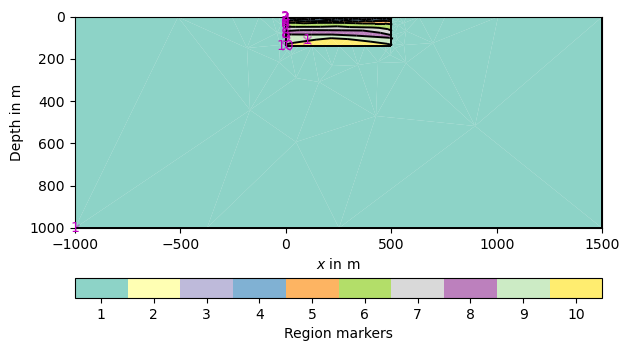

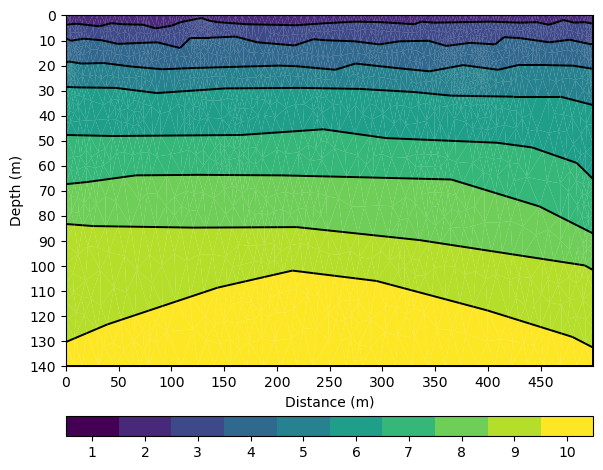

In [2]:
world=mt.createWorld(start=[-1000,0],end=[1500,-1000],worldMarker=1)

poly=mt.createRectangle(start=[0, -140], end=[500, 0], marker=1)

interfaces = []

for i in range(9):

    coords = np.loadtxt(f'shape_{i}.txt')
    line = mt.createPolygon(coords, isClosed=False)
    interfaces.append(line)

geom = mt.mergePLC([world] + interfaces + [poly])

geom.addRegionMarker(pos=[0, -1], marker=2)
geom.addRegionMarker(pos=[0, -6], marker=3)
geom.addRegionMarker(pos=[0, -12], marker=4)
geom.addRegionMarker(pos=[0, -23], marker=5)
geom.addRegionMarker(pos=[0, -40], marker=6)
geom.addRegionMarker(pos=[0, -60], marker=7)
geom.addRegionMarker(pos=[0, -80], marker=8)
geom.addRegionMarker(pos=[0, -100], marker=9)
geom.addRegionMarker(pos=[0, -140], marker=10)


pg.show(geom,showMesh=True,quality=34)

mesh_cut = mt.createMesh(geom, quality=34)

x_min,x_max= 0,500
y_min,y_max= -140,0

ax, cbar = pg.show(mesh_cut, data=mesh_cut.cellMarkers(), 
                   showMesh=False, aspect='auto', 
                   cmap=plt.get_cmap("viridis", 10))
cbar.mappable.set_clim(0.5, 10.5)
cbar.set_ticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

ax.set_xlim(0, 500)
ax.set_ylim(-140, 0)
ax.set_yticks(np.arange(-140, 1, 10)) 
ax.set_xticks(np.arange(0, 500, 50)) 
ax.set_xlabel("Distance (m)")   
ax.set_ylabel("Depth (m)")

plt.draw()

16/03/26 - 18:20:52 - pyGIMLi - INFO - Cache c:\Users\sider\.conda\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 11): C:\Users\sider\AppData\Roaming\pygimli\Cache\17970140561219481632


Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'valid']


(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>,
 <matplotlib.colorbar.Colorbar at 0x23e9205ca10>)

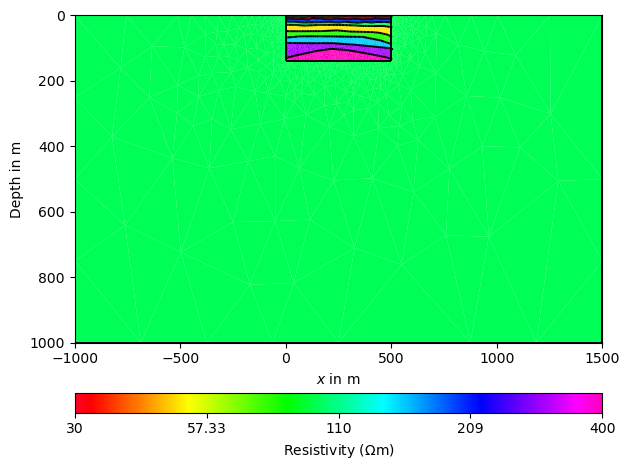

In [3]:
spacing=25
scheme=ert.createData(
    elecs=np.linspace(start=0,stop=500,num=len(np.arange(0,501,spacing)))
    , schemeName='dd'
)
print(scheme)
for p in scheme.sensors():
    geom.createNode(p)
    geom.createNode(p-[0,0.1]) # create 2  nodes for FTDT
mesh_fwr=mt.createMesh(geom,quality=34)
rhomap=[[1,100],
        [2,100],
        [3,30],
        [4,200],
        [5,100],
        [6,50],
        [7,80],
        [8,150],
        [9,300],
        [10,400]
        ] # resistivity για κάθε marker
pg.show(mesh_fwr,data=rhomap,label=pg.unit('res'), cMap='gist_rainbow',logScale=True,aspect='auto')

16/03/26 - 18:20:54 - pyGIMLi - INFO - Data error estimate (min:max)  0.01000646453191016 : 0.01477671087397909


relativeError set to a value > 0.5 .. assuming this is a percentage Error level dividing them by 100
Value for marker 6: 60 Ohm.m, data saved to timelapse_0.dat
Log0.txt created with details of Step 0
Done Step 0


16/03/26 - 18:20:55 - pyGIMLi - INFO - Data error estimate (min:max)  0.010006464776187888 : 0.014831885951130209


relativeError set to a value > 0.5 .. assuming this is a percentage Error level dividing them by 100
Value for marker 6: 57 Ohm.m, data saved to timelapse_1.dat
Log1.txt created with details of Step 1
Done Step 1


16/03/26 - 18:20:56 - pyGIMLi - INFO - Data error estimate (min:max)  0.010006464886587687 : 0.014871259216716599


...

16/03/26 - 18:21:01 - pyGIMLi - INFO - Data error estimate (min:max)  0.010006414159357331 : 0.018404632948980038


relativeError set to a value > 0.5 .. assuming this is a percentage Error level dividing them by 100
Value for marker 6: 10 Ohm.m, data saved to timelapse_8.dat
Log8.txt created with details of Step 8
Done Step 8


16/03/26 - 18:21:02 - pyGIMLi - INFO - Data error estimate (min:max)  0.01000638204193834 : 0.02295302445376775


relativeError set to a value > 0.5 .. assuming this is a percentage Error level dividing them by 100
Value for marker 6: 5 Ohm.m, data saved to timelapse_9.dat
Log9.txt created with details of Step 9
Done Step 9


(<Axes: xlabel='a', ylabel='m'>,
 <matplotlib.colorbar.Colorbar at 0x23e995b2b50>)

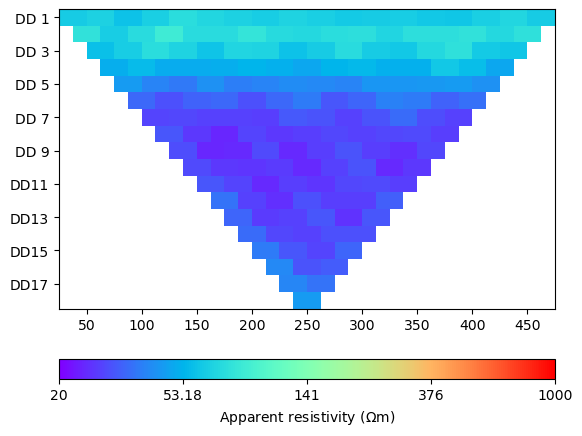

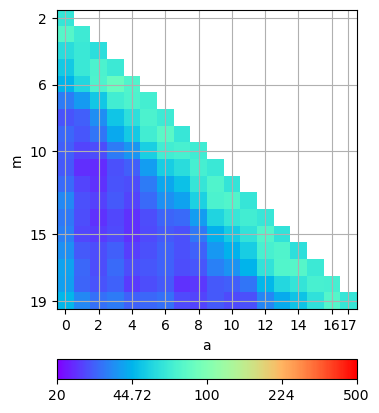

In [4]:
#timelapse, changing marker6 (layer 6), assume it changes due to pollution
new_vals=[60,57,55,53,50,40,30,20,10,5]
for i, rho_val in enumerate(new_vals):
    rhomap[5][1]=rho_val
    data=ert.simulate(mesh_fwr,scheme=scheme, res=rhomap, noiseLevel=1, noiseAbs=1e-6, seed=1337)
    data.remove(data['rhoa']<0)

    filename=f'timelapse_{i}.dat'
    print(f'Value for marker 6: {new_vals[i]} Ohm.m, data saved to {filename}')
    with open(f'log{i}.txt', 'w') as f:
        print(f"Step {i} | Marker6: {rho_val} ", file=f)
        print(f"Norm Err: {np.linalg.norm(data['err'])}", file=f)
        print(f"Min/Max Rhoa: {min(data['rhoa'])} / {max(data['rhoa'])}", file=f)
        print(f"Data: {data}", file=f)
    print(f'Log{i}.txt created with details of Step {i}')
    data.save(filename)
    print(f'Done Step {i}')

    np.save(f'res_all_t_{i}.npy', np.column_stack([data['rhoa']])) #Resistivity changes, keep inside the loop


np.save(f'abmn_timelapse.npy', np.column_stack([data['a'], data['b'], data['m'], data['n']])) #Geometry doesn't change.

ert.show(data,cMap='rainbow',cMin=20,cMax=1000,logScale=True,title='DD')   #pseudosection for last step (confirmation)
pg.viewer.mpl.showDataContainerAsMatrix(data,'a','m', 'rhoa',cMap='rainbow',cMin=20,cMax=500,logScale=True,title='DD')


In [8]:
# Function to handle NaN values and get the NaN mask

def fill_nan(image):
    
    nan_mask = np.isnan(image)
    mean_value = np.nanmean(image)
    image[nan_mask] = mean_value

    return image, nan_mask


# Function to reconstruct the image using significant indices and their values

def reconstruct_compressed_image(image_shape, significant_indices, pixel_values):

    # Create an empty image with the given shape
    compressed_image = np.full(image_shape, np.nan)

    # Assign the provided pixel values to the significant indices
    compressed_image[significant_indices] = pixel_values

    # Interpolate to fill in the missing values
    x, y = np.meshgrid(np.arange(image_shape[1]), np.arange(image_shape[0]))
    mask = ~np.isnan(compressed_image)
    interpolated_image = griddata(
        (x[mask], y[mask]),  # Points with known values
        compressed_image[mask],  # Known values
        (x, y),  # Points to interpolate
        method='linear'  # Interpolation 
        )
    return interpolated_image


# Function to perform SVD and reconstruct image using significant pixels

def compress_and_reconstruct(image, num_singular_values,method='DD'):

    # Handle NaN values and get the NaN mask
    image, nan_mask = fill_nan(image)

    # Perform SVD
    U, S, Vt = np.linalg.svd(image, full_matrices=False)

    # Keep only the top 'num_singular_values' singular values
    U_reduced = U[:, :num_singular_values]
    S_reduced = np.diag(S[:num_singular_values])
    Vt_reduced = Vt[:num_singular_values, :]

    # Reconstruct the image using significant pixels
    compressed_image = np.dot(U_reduced, np.dot(S_reduced, Vt_reduced))

    # Identify significant pixel indices based on contributions
    contributions = np.abs(U_reduced) @ np.abs(Vt_reduced)

    rows,cols = np.arange(image.shape[0]),np.arange(image.shape[1])
 
    z=rows/np.max(rows)
    if method == 'SLM':
        z_factor = 0.6
    elif method == 'DD':
        # 0.4 for SLM, 0.2 for DD
        z_factor = 0.5
    else:
        print('error, choose method')

    depth_weight=1+z_factor*z   
    depth_weight=depth_weight[:,None] #2D IMPORTANT!!! 1D->WEIGHTING MORE TO DISTANT PIXELS  
    contributions*=depth_weight

    contributions[nan_mask] = -np.inf
    rows_0=np.where(~nan_mask[:,0])[0] #only non-nans for the fist column to force the linear interp   

    if len(rows_0)>0:
        r_min=rows_0[0]
        r_max=rows_0[-1]
        r_med=rows_0[len(rows_0)//2]
        contributions[r_min,0]=np.inf 
        contributions[r_max,0]=np.inf
        contributions[r_med,0]=np.inf   #force to include them

    flat_indices = np.argsort(contributions.flatten())[::-1][:num_singular_values]

    #flat_indices=np.r_[0,image.shape[0]*image.shape[1]-1,flat_indices]
    #Convert flat indices to 2D indices

    significant_indices = np.unravel_index(flat_indices, image.shape)

    #Restore NaN values in the original positions
    compressed_image[nan_mask] = np.nan
 
    return compressed_image, significant_indices,nan_mask


#Function to plot ERT measurements as a checkerboard heatmap

def plot_ert_checkerboard(data,plot=0):

    """
    Plots ERT measurements as a checkerboard heatmap.
    Parameters:
    data (pd.DataFrame): A DataFrame containing columns 'A', 'B', 'M', 'N', and 'Res'.
    """

    #Extract unique electrode positions
    electrodes = np.unique(data[['A', 'B', 'M', 'N']].values)
    electrode_map = {electrode: idx for idx, electrode in enumerate(sorted(electrodes))}

    #Create a grid
    grid_size = len(electrode_map)
    heatmap = np.full((grid_size, grid_size), np.nan)

    #Map values to the grid
    for _, row in data.iterrows():
        x = electrode_map[row['A']]
        y = electrode_map[row['M']]
        heatmap[y, x] = row['Res']


    if plot==1:

        #Plot the checkerboard heatmap
        plt.figure(figsize=(10, 8))
        plt.imshow(np.log10(heatmap), cmap='gist_rainbow', interpolation='nearest')
        plt.colorbar(label='ERT Measurement Value')

        plt.xticks(ticks=np.arange(grid_size), labels=sorted(electrode_map.keys()), rotation=90)
        plt.yticks(ticks=np.arange(grid_size), labels=sorted(electrode_map.keys()))

        plt.xlabel('Electrode A')
        plt.ylabel('Electrode N')
        plt.title('ERT Checkerboard Heatmap')

        plt.show()
    return heatmap


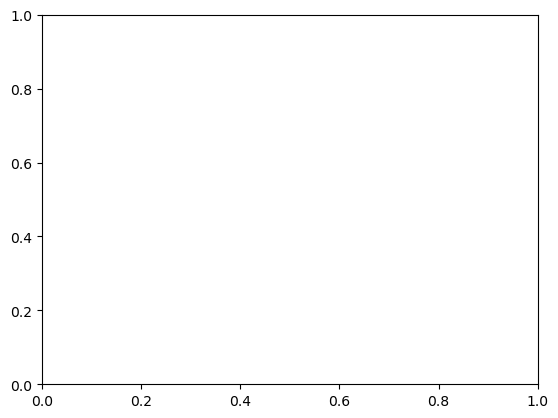

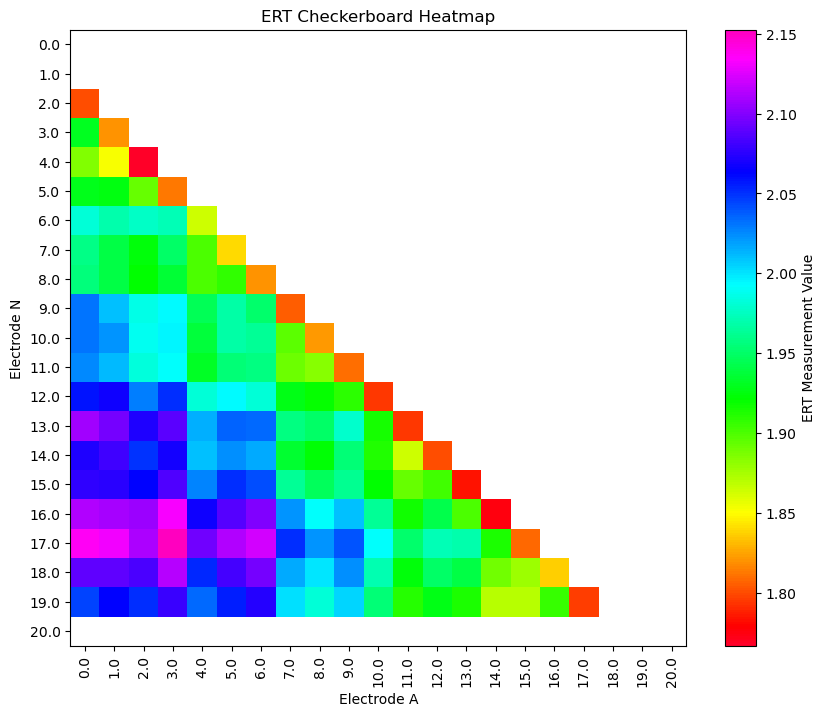

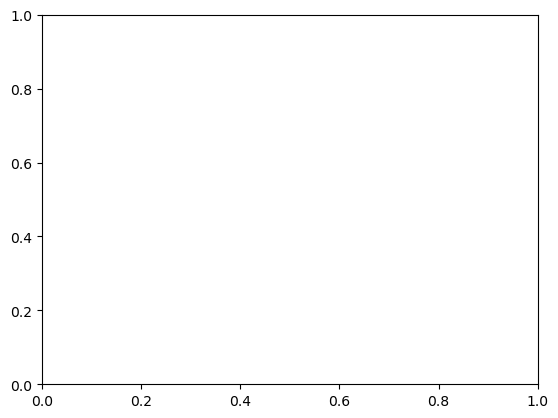

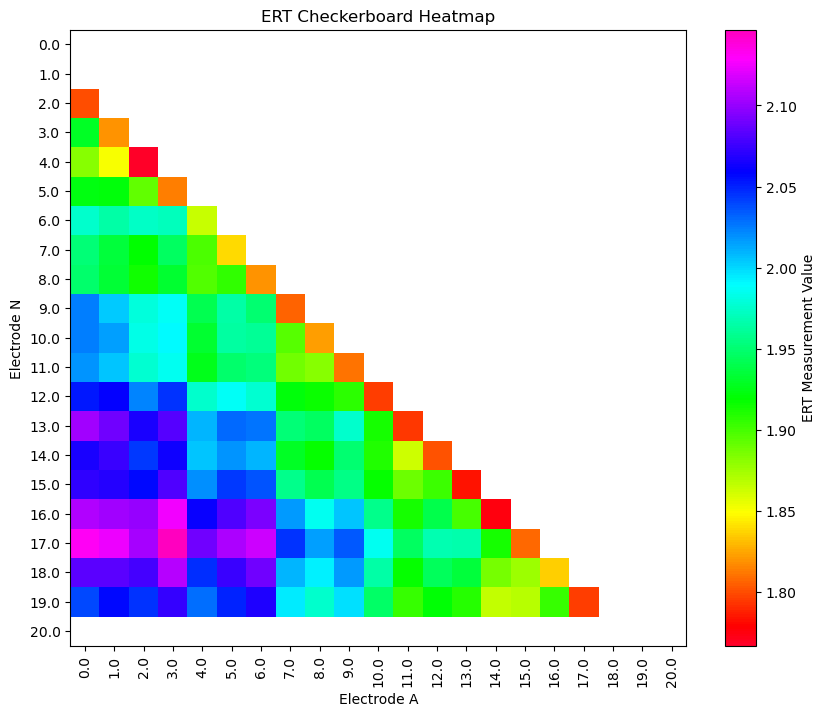

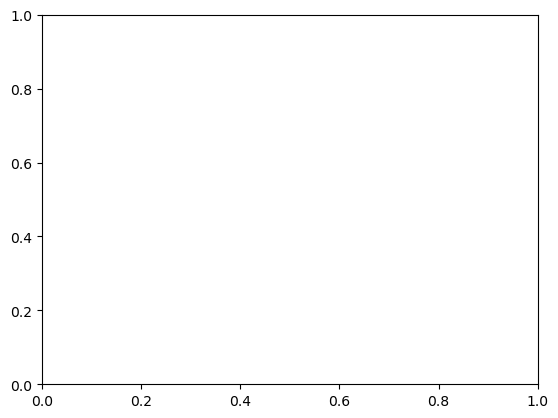

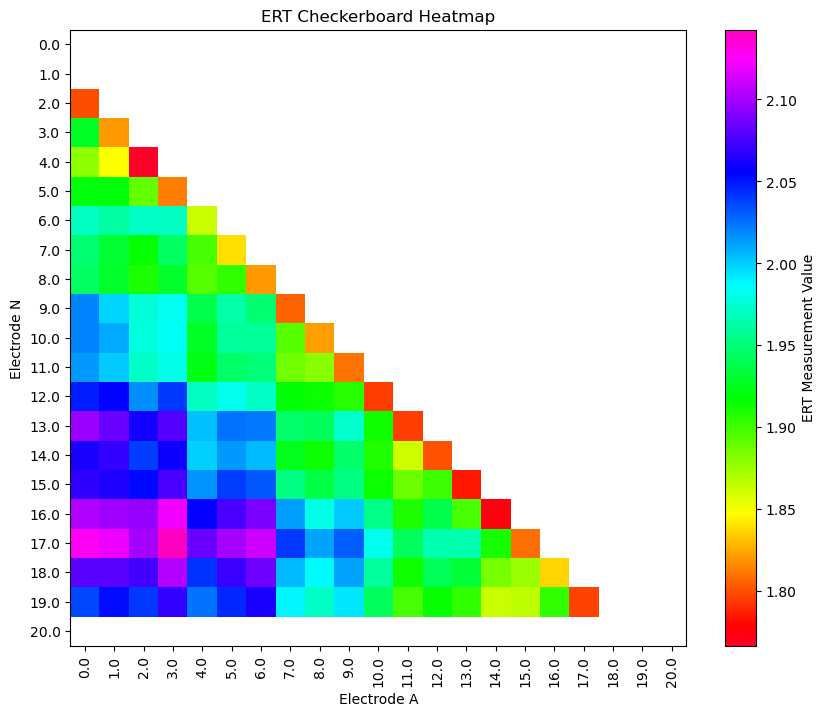

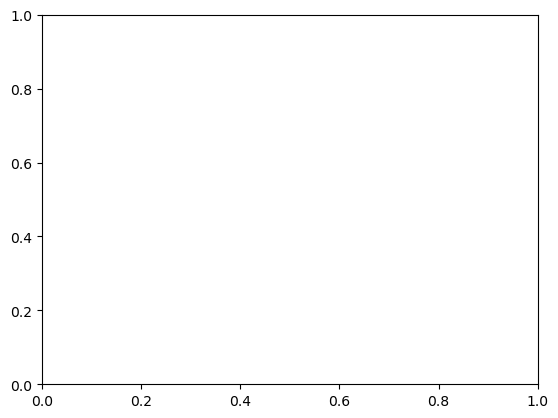

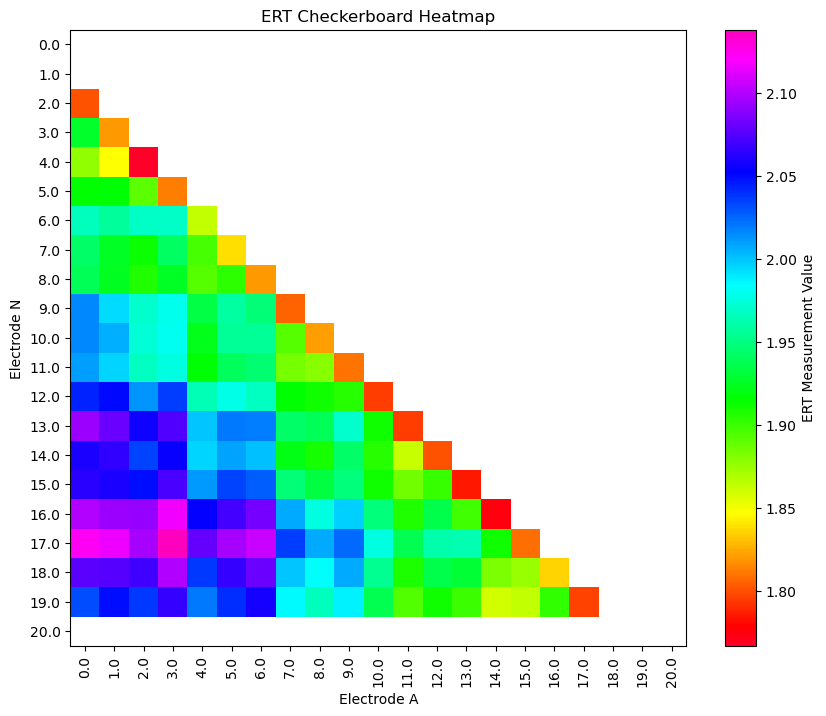

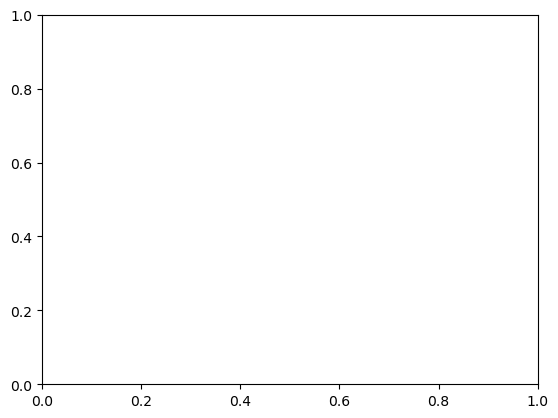

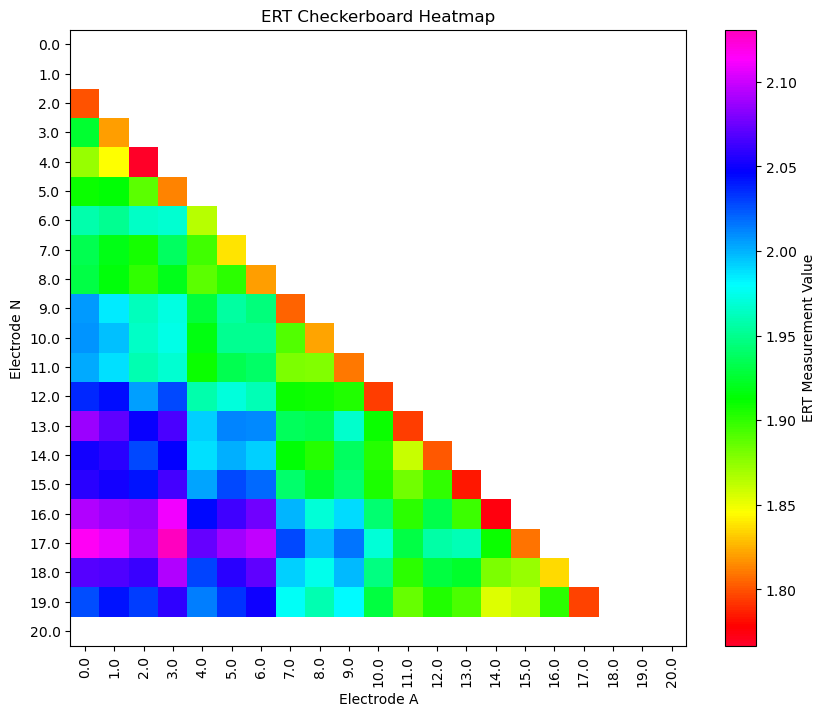

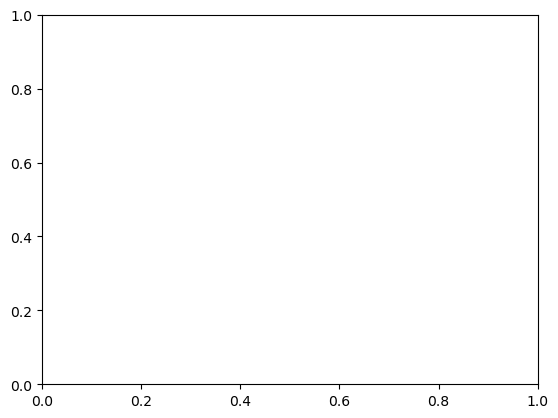

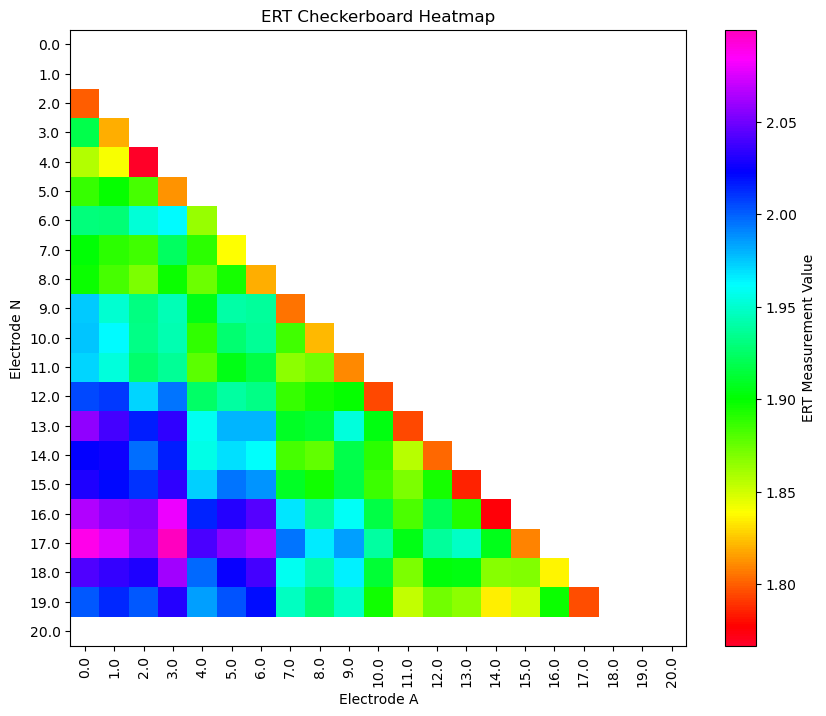

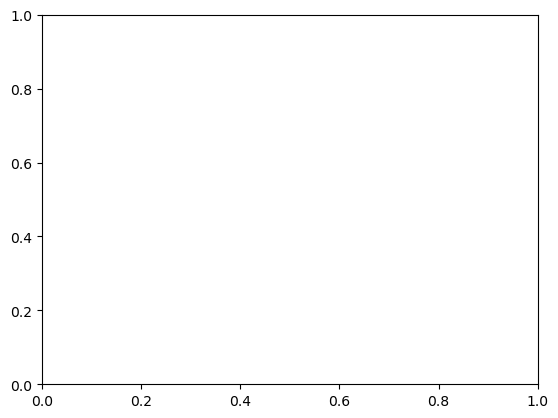

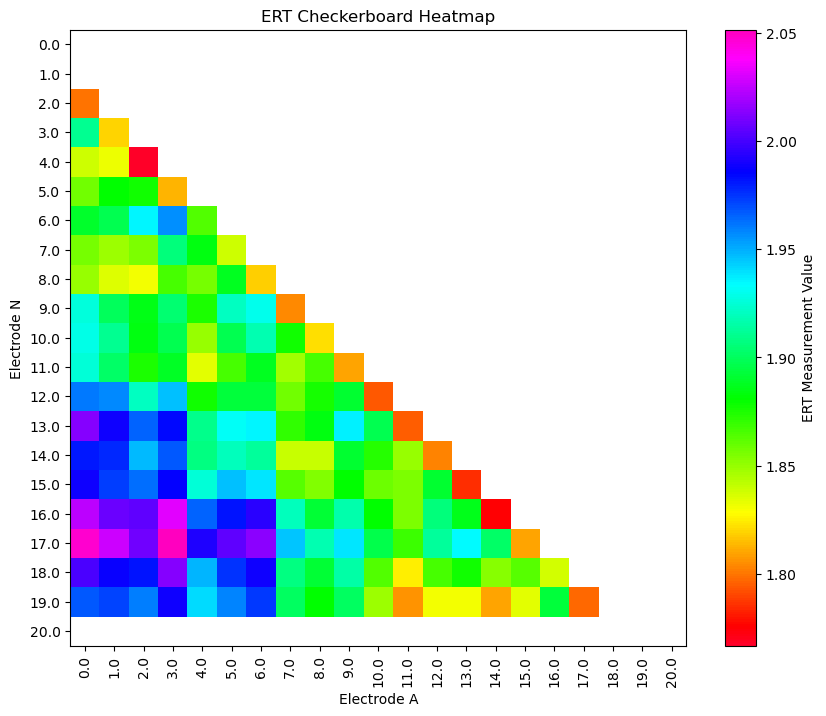

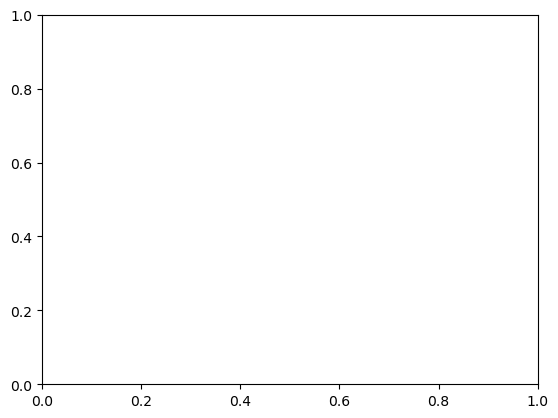

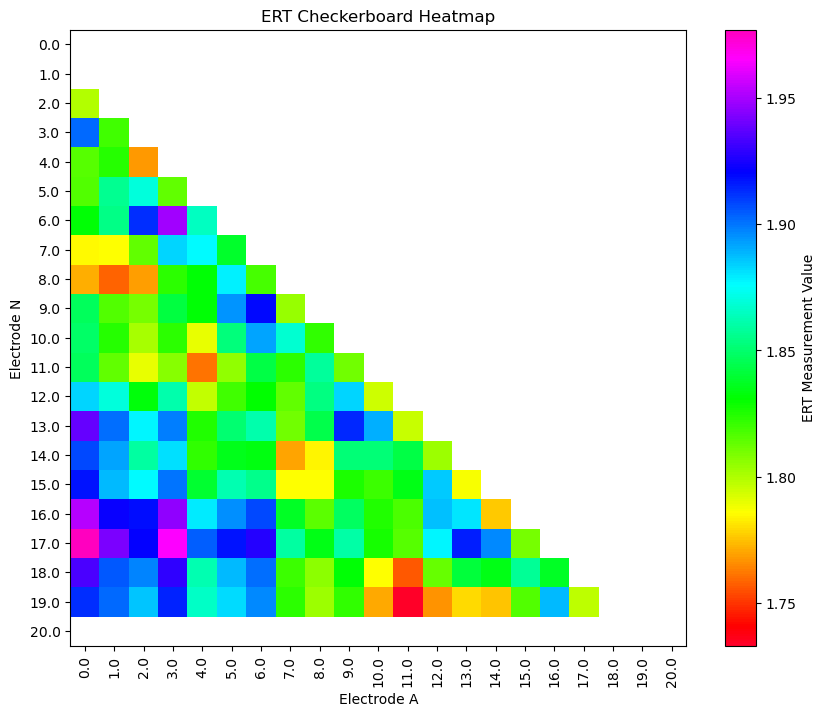

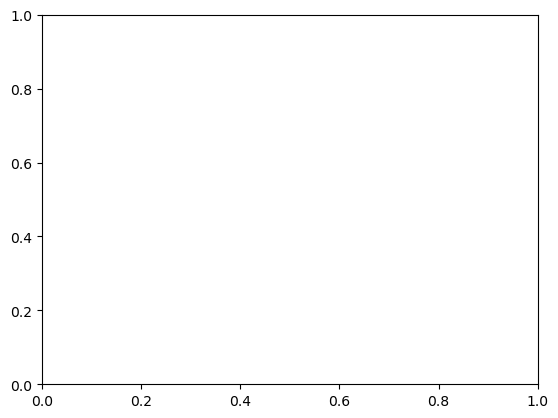

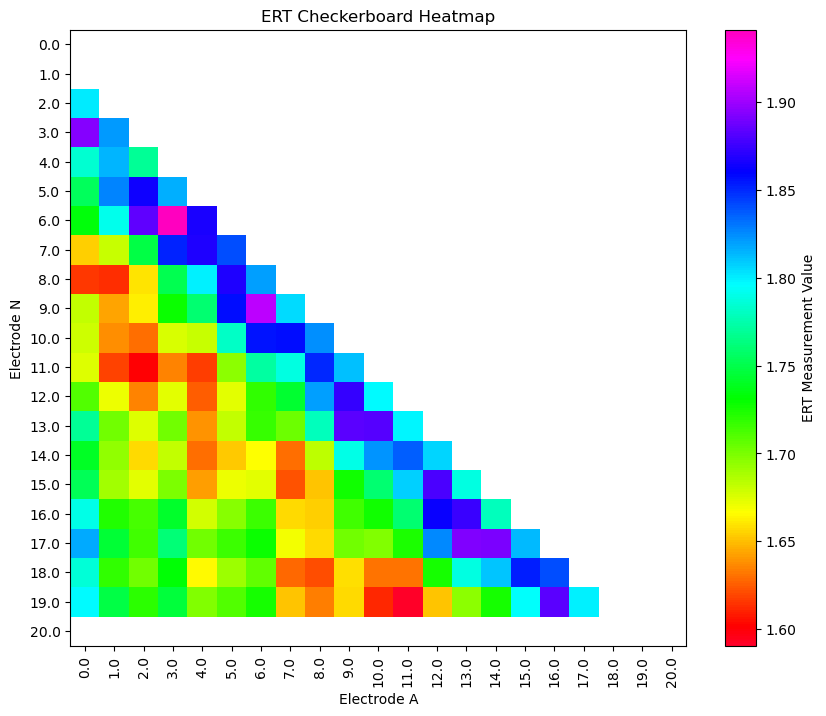

In [ ]:
abmn=np.load('abmn_timelapse.npy')
for i in range(9):
    res_all=np.load(f'res_all_t_{i}.npy')
    data_all=np.column_stack([abmn,res_all[:,0]])
    data=pd.DataFrame(data_all,columns=['A','B','M','N','Res'])
    image=plt.subplot
    plot_ert_checkerboard(data,plot=1)        